In [1]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms.functional import resize
from torchvision.transforms import InterpolationMode
import random
from sklearn.model_selection import train_test_split

In [2]:
os.chdir('/home/ntdung/Medical')

In [3]:
excel_path = 'data/participants.xlsx'
df = pd.read_excel(excel_path, nrows=None)
df

,No.,subject_age,subject_dx,subject_sex,subject_id,dataset_name
0,1,44.2,control,m,sub-BrainAge000019,ABIDE/Caltech
1,2,39.3,control,m,sub-BrainAge000020,ABIDE/Caltech
2,3,42.5,control,m,sub-BrainAge000021,ABIDE/Caltech
3,4,19.7,control,m,sub-BrainAge000022,ABIDE/Caltech
4,5,20.0,control,f,sub-BrainAge000023,ABIDE/Caltech
...,...,...,...,...,...,...
4943,4944,66.0,control,f,sub-BrainAge023209,RocklandSample
4944,4945,69.0,control,m,sub-BrainAge023210,RocklandSample
4945,4946,23.0,control,m,sub-BrainAge023211,RocklandSample
4946,4947,54.0,control,f,sub-BrainAge023212,RocklandSample


In [4]:
def is_integer(n):
    return float(n).is_integer()

n_total = len(df)
n_integer = df['subject_age'].apply(is_integer).sum()
n_decimal = n_total - n_integer

print(f"Samples with integer age values: {n_integer}")
print(f"Samples with decimal age values: {n_decimal}")

Samples with integer age values: 4242
Samples with decimal age values: 706


In [5]:
df['subject_age'] = df['subject_age'].round().astype(int)
df

,No.,subject_age,subject_dx,subject_sex,subject_id,dataset_name
0,1,44,control,m,sub-BrainAge000019,ABIDE/Caltech
1,2,39,control,m,sub-BrainAge000020,ABIDE/Caltech
2,3,42,control,m,sub-BrainAge000021,ABIDE/Caltech
3,4,20,control,m,sub-BrainAge000022,ABIDE/Caltech
4,5,20,control,f,sub-BrainAge000023,ABIDE/Caltech
...,...,...,...,...,...,...
4943,4944,66,control,f,sub-BrainAge023209,RocklandSample
4944,4945,69,control,m,sub-BrainAge023210,RocklandSample
4945,4946,23,control,m,sub-BrainAge023211,RocklandSample
4946,4947,54,control,f,sub-BrainAge023212,RocklandSample


In [6]:
def load_middle_slices(nii_path):
    img = nib.load(nii_path).get_fdata()

    x, y, z = img.shape
    axial_slice = img[:, :, z // 2]
    sagittal_slice = img[x // 2, :, :]
    coronal_slice = img[:, y // 2, :]

    # Normalize
    axial_slice = (axial_slice - axial_slice.min()) / (axial_slice.max() - axial_slice.min())
    sagittal_slice = (sagittal_slice - sagittal_slice.min()) / (sagittal_slice.max() - sagittal_slice.min())
    coronal_slice = (coronal_slice - coronal_slice.min()) / (coronal_slice.max() - coronal_slice.min())

    return axial_slice, sagittal_slice, coronal_slice

In [12]:
class BrainMRIDataset(Dataset):
    def __init__(self, dataframe, root_dir, output_size):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.output_size = output_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        subject_id = row['subject_id']
        age = row['subject_age']
        sex = 0 if row['subject_sex'] == 'm' else 1

        nii_path = os.path.join(self.root_dir, subject_id, 'anat', f'{subject_id}_T1w.nii.gz')
        axial, sagittal, coronal = load_middle_slices(nii_path)

        # Stack to tensor (3, H, W)
        image = np.stack([axial, sagittal, coronal], axis=0).astype(np.float32)
        image_tensor = torch.tensor(image)

        # Resize to (3, 128, 128)
        image_resized = resize(image_tensor, size=[self.output_size, self.output_size], interpolation=InterpolationMode.BILINEAR)

        while True:
            cf_idx = random.randint(0, len(self.df) - 1)
            if cf_idx != idx:
                break
        cf_row = self.df.iloc[cf_idx]
        cf_age = cf_row['subject_age']
        cf_sex = 0 if cf_row['subject_sex'] == 'm' else 1

        return {
            'image': image_resized,
            'age': torch.tensor(age, dtype=torch.float32),
            'sex': torch.tensor(sex, dtype=torch.long),
            'cf_age': torch.tensor(cf_age, dtype=torch.float32),
            'cf_sex': torch.tensor(cf_sex, dtype=torch.long),
            'subject_id': subject_id
        }


In [35]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_dataset = BrainMRIDataset(train_df, 'data', 128)
test_dataset = BrainMRIDataset(test_df, 'data', 128)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [36]:
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Number of batches in train_loader: 1979
Number of batches in test_loader: 495


In [37]:
first_batch = next(iter(train_loader))
print("Image shape:", first_batch['image'].shape)  # (B, 3, H, W)
print("Age:", first_batch['age'])
print("Sex:", first_batch['sex'])
print("CF Age:", first_batch['cf_age'])
print("CF Sex:", first_batch['cf_sex'])
print("Subject IDs:", first_batch['subject_id'])

Image shape: torch.Size([2, 3, 128, 128])
Age: tensor([26., 71.])
Sex: tensor([1, 1])
CF Age: tensor([60., 72.])
CF Sex: tensor([1, 0])
Subject IDs: ['sub-BrainAge018990', 'sub-BrainAge020764']


In [13]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.distributions.normal import Normal
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random

# Thiết lập seed để kết quả tái tạo được
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

os.chdir('/home/ntdung/Medical')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Tìm thấy 4924 mẫu có dữ liệu MRI hợp lệ
Shape của lát cắt axial: torch.Size([1, 130, 130])
Shape của lát cắt sagittal: torch.Size([1, 130, 130])
Shape của lát cắt coronal: torch.Size([1, 130, 130])
Điều kiện (age, gender): tensor([0.3316, 0.0000])


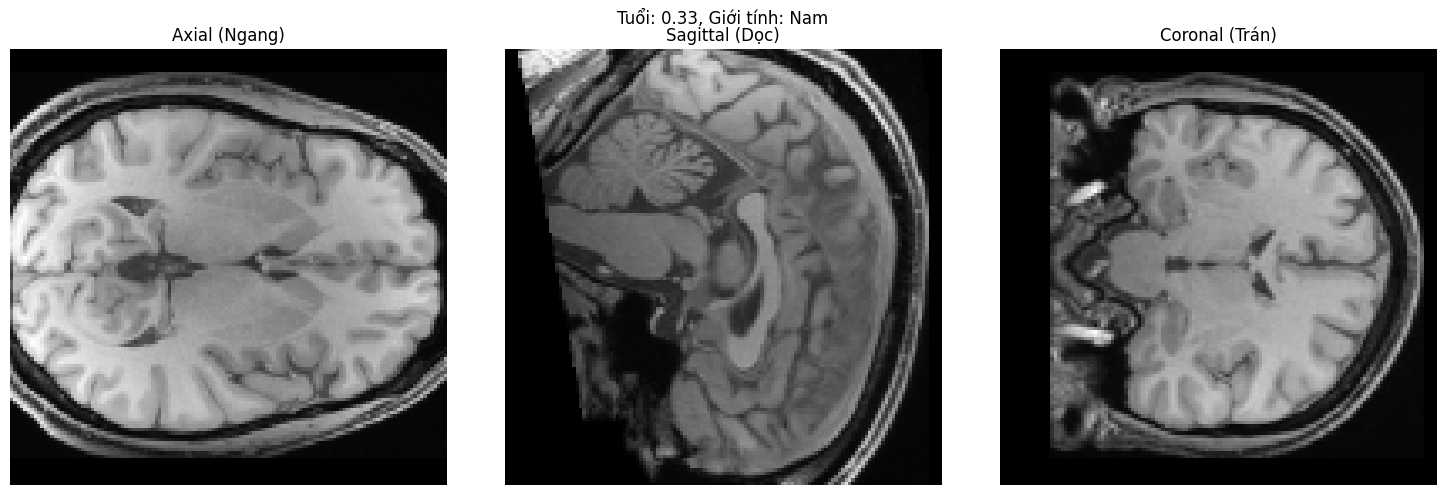

Batch shape của lát cắt axial: torch.Size([4, 1, 130, 130])
Batch shape của điều kiện: torch.Size([4, 2])


In [14]:
class BrainMRIDataset(Dataset):
    """
    Dataset cho Brain MRI với thông tin tuổi và giới tính
    """
    def __init__(self, data_dir, participants_file, transform=None):
        """
        Khởi tạo Dataset
        
        Parameters:
            data_dir (str): Đường dẫn đến thư mục chứa dữ liệu
            participants_file (str): Đường dẫn đến file Excel chứa thông tin người tham gia
            transform (callable, optional): Các phép biến đổi tùy chọn
        """
        self.data_dir = data_dir
        self.transform = transform
        
        # Đọc file thông tin người tham gia
        self.participants_df = pd.read_excel(participants_file)
        
        # Chuẩn hóa giới tính thành giá trị số
        self.participants_df['gender_code'] = self.participants_df['subject_sex'].map({'m': 0, 'f': 1})
        
        # Chuẩn hóa tuổi (min-max scaling)
        self.min_age = self.participants_df['subject_age'].min()
        self.max_age = self.participants_df['subject_age'].max()
        self.participants_df['age_normalized'] = (self.participants_df['subject_age'] - self.min_age) / (self.max_age - self.min_age)
        
        # Lọc các subject có dữ liệu MRI
        valid_subjects = []
        for _, row in self.participants_df.iterrows():
            subject_id = row['subject_id']
            file_path = os.path.join(data_dir, subject_id, 'anat', f"{subject_id}_T1w.nii.gz")
            if os.path.exists(file_path):
                valid_subjects.append(subject_id)
        
        # Chỉ giữ lại các subject có dữ liệu
        self.participants_df = self.participants_df[self.participants_df['subject_id'].isin(valid_subjects)]
        print(f"Tìm thấy {len(self.participants_df)} mẫu có dữ liệu MRI hợp lệ")
    
    def __len__(self):
        return len(self.participants_df)
    
    def __getitem__(self, idx):
        # Lấy thông tin subject
        subject_info = self.participants_df.iloc[idx]
        subject_id = subject_info['subject_id']
        
        # Đường dẫn đến file MRI
        file_path = os.path.join(self.data_dir, subject_id, 'anat', f"{subject_id}_T1w.nii.gz")
        
        # Đọc file MRI
        img = nib.load(file_path)
        img_data = img.get_fdata()
        
        # Lấy 3 lát cắt giữa (middle slices)
        axial_slice = img_data[:, :, img_data.shape[2]//2]  # Lát cắt axial (ngang)
        sagittal_slice = img_data[img_data.shape[0]//2, :, :]  # Lát cắt sagittal (dọc)
        coronal_slice = img_data[:, img_data.shape[1]//2, :]  # Lát cắt coronal (trán)
        
        # Chuyển đổi thành tensor PyTorch và chuẩn hóa về dải [0, 1]
        axial_slice = torch.from_numpy(axial_slice).float()
        sagittal_slice = torch.from_numpy(sagittal_slice).float()
        coronal_slice = torch.from_numpy(coronal_slice).float()
        
        # Min-max normalization cho mỗi lát cắt
        axial_slice = (axial_slice - axial_slice.min()) / (axial_slice.max() - axial_slice.min() + 1e-8)
        sagittal_slice = (sagittal_slice - sagittal_slice.min()) / (sagittal_slice.max() - sagittal_slice.min() + 1e-8)
        coronal_slice = (coronal_slice - coronal_slice.min()) / (coronal_slice.max() - coronal_slice.min() + 1e-8)
        
        # Thêm chiều kênh (channel dimension)
        axial_slice = axial_slice.unsqueeze(0)      # [1, H, W]
        sagittal_slice = sagittal_slice.unsqueeze(0)  # [1, H, W]
        coronal_slice = coronal_slice.unsqueeze(0)   # [1, H, W]
        
        # Lấy thông tin điều kiện (condition): tuổi và giới tính
        age = torch.tensor(subject_info['age_normalized'], dtype=torch.float32)
        gender = torch.tensor(subject_info['gender_code'], dtype=torch.float32)
        
        # Đóng gói kết quả
        slices = {
            'axial': axial_slice,
            'sagittal': sagittal_slice,
            'coronal': coronal_slice
        }
        
        condition = torch.tensor([age, gender], dtype=torch.float32)
        
        return slices, condition

# Hàm để hiển thị lát cắt MRI
def show_brain_slices(slices, title=None):
    """
    Hiển thị 3 lát cắt não MRI
    
    Parameters:
        slices (dict): Dictionary chứa 3 lát cắt 'axial', 'sagittal', 'coronal'
        title (str, optional): Tiêu đề
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Hiển thị lát cắt axial
    axes[0].imshow(slices['axial'][0].cpu().numpy(), cmap='gray')
    axes[0].set_title('Axial (Ngang)')
    axes[0].axis('off')
    
    # Hiển thị lát cắt sagittal
    axes[1].imshow(slices['sagittal'][0].cpu().numpy(), cmap='gray')
    axes[1].set_title('Sagittal (Dọc)')
    axes[1].axis('off')
    
    # Hiển thị lát cắt coronal
    axes[2].imshow(slices['coronal'][0].cpu().numpy(), cmap='gray')
    axes[2].set_title('Coronal (Trán)')
    axes[2].axis('off')
    
    if title:
        fig.suptitle(title)
    
    plt.tight_layout()
    plt.show()

# Ví dụ sử dụng Dataset
if __name__ == "__main__":
    # Đường dẫn dữ liệu
    data_dir = "data"  # Thay đổi thành đường dẫn thực tế
    participants_file = "data/participants_1.xlsx"  # Thay đổi thành đường dẫn thực tế
    
    # Tạo dataset
    dataset = BrainMRIDataset(data_dir, participants_file)
    
    # Kiểm tra một mẫu
    sample_slices, sample_condition = dataset[0]
    print(f"Shape của lát cắt axial: {sample_slices['axial'].shape}")
    print(f"Shape của lát cắt sagittal: {sample_slices['sagittal'].shape}")
    print(f"Shape của lát cắt coronal: {sample_slices['coronal'].shape}")
    print(f"Điều kiện (age, gender): {sample_condition}")
    
    # Hiển thị lát cắt
    show_brain_slices(sample_slices, f"Tuổi: {sample_condition[0]:.2f}, Giới tính: {'Nữ' if sample_condition[1] == 1 else 'Nam'}")
    
    # Tạo DataLoader
    batch_size = 4
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Kiểm tra một batch
    for batch_slices, batch_conditions in dataloader:
        print(f"Batch shape của lát cắt axial: {batch_slices['axial'].shape}")
        print(f"Batch shape của điều kiện: {batch_conditions.shape}")
        break

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.normal import Normal

class SpatialTransformer2D(nn.Module):
    """
    2D Spatial Transformer cho từng lát cắt
    """
    def __init__(self, size, mode='bilinear', get_unnormed=False):
        super().__init__()
        self.mode = mode

        # Tạo lưới lấy mẫu
        vectors = [torch.arange(0, s) for s in size]
        grids = torch.meshgrid(vectors)
        grid = torch.stack(grids)
        grid = torch.unsqueeze(grid, 0)

        self.register_buffer('grid', grid)
        self.get_unnormed = get_unnormed

    def forward(self, src, flow):
        # Vị trí mới
        new_locs = self.grid + flow
        shape = flow.shape[2:]
        unnormed_locs = torch.clone(new_locs)

        # Chuẩn hóa giá trị lưới về [-1, 1] để sử dụng grid_sample
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2 * (new_locs[:, i, ...] / (shape[i] - 1) - 0.5)

        # Chuyển đổi cho lát cắt 2D
        new_locs = new_locs.permute(0, 2, 3, 1)
        new_locs = new_locs[..., [1, 0]]  # x, y cho lát cắt 2D

        # Trả về lưới không chuẩn hóa nếu cần thiết (cho mục đích hiển thị)
        if self.get_unnormed:
            return F.grid_sample(src, new_locs, align_corners=True, mode=self.mode), unnormed_locs
        else:
            return F.grid_sample(src, new_locs, align_corners=True, mode=self.mode)


class VecInt2D(nn.Module):
    """
    Tích hợp trường vectơ qua kỹ thuật scaling and squaring (dành cho 2D)
    """
    def __init__(self, inshape, nsteps):
        super().__init__()
        assert nsteps >= 0, 'nsteps should be >= 0, found: %d' % nsteps
        self.nsteps = nsteps
        self.scale = 1.0 / (2 ** self.nsteps)
        self.transformer = SpatialTransformer2D(inshape)

    def forward(self, vec):
        vec = vec * self.scale
        for _ in range(self.nsteps):
            vec = vec + self.transformer(vec, vec)
        return vec


class ResizeTransform2D(nn.Module):
    """
    Thay đổi kích thước biến đổi, bao gồm việc thay đổi kích thước trường vectơ và điều chỉnh tỷ lệ
    """
    def __init__(self, vel_resize):
        super().__init__()
        self.factor = 1.0 / vel_resize
        self.mode = 'bilinear'  # Luôn là 2D

    def forward(self, x):
        if self.factor < 1:
            # Thay đổi kích thước trước để tiết kiệm bộ nhớ
            x = F.interpolate(x, align_corners=True, scale_factor=self.factor, mode=self.mode)
            x = self.factor * x
        elif self.factor > 1:
            # Nhân trước để tiết kiệm bộ nhớ
            x = self.factor * x
            x = F.interpolate(x, align_corners=True, scale_factor=self.factor, mode=self.mode)
        # Không làm gì nếu tỷ lệ là 1
        return x


class ConvBlock2D(nn.Module):
    """
    Khối tích chập 2D theo sau là LeakyReLU.
    """
    def __init__(self, in_channels, out_channels, stride=1, kernel_size=3, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.activation = nn.LeakyReLU(0.2)
        self.norm = nn.InstanceNorm2d(out_channels)  # Thêm InstanceNorm cho hiệu quả tốt hơn

    def forward(self, x):
        out = self.conv(x)
        out = self.norm(out)
        out = self.activation(out)
        return out


# Kiểm tra các lớp cơ bản
if __name__ == "__main__":
    # Kiểm tra ConvBlock2D
    x = torch.randn(4, 16, 128, 128)  # [batch, channels, height, width]
    conv_block = ConvBlock2D(16, 32)
    out = conv_block(x)
    print(f"ConvBlock2D input shape: {x.shape}, output shape: {out.shape}")
    
    # Kiểm tra SpatialTransformer2D
    img = torch.randn(4, 1, 128, 128)  # [batch, channels, height, width]
    flow = torch.zeros(4, 2, 128, 128)  # [batch, 2(x,y), height, width]
    transformer = SpatialTransformer2D((128, 128))
    transformed = transformer(img, flow)
    print(f"SpatialTransformer2D input shape: {img.shape}, output shape: {transformed.shape}")

ConvBlock2D input shape: torch.Size([4, 16, 128, 128]), output shape: torch.Size([4, 32, 128, 128])
SpatialTransformer2D input shape: torch.Size([4, 1, 128, 128]), output shape: torch.Size([4, 1, 128, 128])


/home/ntdung/.local/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [16]:
def default_unet_features_2d():
    """
    Cấu hình mặc định cho các đặc trưng của Unet.
    """
    nb_features = [
        [16, 32, 32, 32],  # encoder
        [32, 32, 32, 32, 32, 16, 16]  # decoder
    ]
    return nb_features


class Unet2D(nn.Module):
    """
    Kiến trúc Unet cho 2D. Các đặc trưng của layer có thể được chỉ định trực tiếp như một danh sách
    của đặc trưng encoder và decoder hoặc như một số nguyên duy nhất cùng với số lượng cấp độ unet.
    """
    def __init__(self, inshape, c_dim, nb_features=None, nb_levels=None, feat_mult=1, in_channels=1):
        super().__init__()
        """
        Tham số:
            inshape: Kích thước đầu vào. ví dụ: (192, 192)
            c_dim: Số chiều của điều kiện (condition dimension)
            nb_features: Đặc trưng tích chập Unet. Có thể được chỉ định thông qua danh sách các danh sách
                với dạng [[đặc trưng encoder], [đặc trưng decoder]], hoặc như một số nguyên duy nhất.
            nb_levels: Số cấp độ trong unet. Chỉ được sử dụng khi nb_features là một số nguyên.
            feat_mult: Bội số của đặc trưng trên mỗi cấp độ. Chỉ được sử dụng khi nb_features là một số nguyên.
            in_channels: Số kênh đầu vào.
        """
        # Đảm bảo kích thước chính xác
        self.c_dim = c_dim
        ndims = len(inshape)
        assert ndims == 2, 'ndims should be 2 for Unet2D. found: %d' % ndims

        # Đặc trưng mặc định của encoder và decoder nếu không có gì được cung cấp
        if nb_features is None:
            nb_features = default_unet_features_2d()

        # Xây dựng danh sách đặc trưng tự động
        if isinstance(nb_features, int):
            if nb_levels is None:
                raise ValueError('must provide unet nb_levels if nb_features is an integer')
            feats = np.round(nb_features * feat_mult ** np.arange(nb_levels)).astype(int)
            self.enc_nf = feats[:-1]
            self.dec_nf = np.flip(feats)
        elif nb_levels is not None:
            raise ValueError('cannot use nb_levels if nb_features is not an integer')
        else:
            self.enc_nf, self.dec_nf = nb_features

        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

        # Cấu hình encoder (đường dẫn lấy mẫu xuống)
        prev_nf = in_channels + c_dim
        self.downarm = nn.ModuleList()
        for nf in self.enc_nf:
            self.downarm.append(ConvBlock2D(prev_nf, nf, stride=2))
            prev_nf = nf

        self.nf_encoder = prev_nf

        # Cấu hình decoder (đường dẫn lấy mẫu lên)
        enc_history = list(reversed(self.enc_nf))
        self.uparm = nn.ModuleList()
        for i, nf in enumerate(self.dec_nf[:len(self.enc_nf)]):
            channels = prev_nf + enc_history[i] if i > 0 else prev_nf
            self.uparm.append(ConvBlock2D(channels, nf, stride=1))
            prev_nf = nf

        self.decoder_nf = prev_nf

        # Cấu hình các lớp tích chập bổ sung của decoder (không lấy mẫu lên)
        prev_nf += in_channels + c_dim
        self.extras = nn.ModuleList()
        for nf in self.dec_nf[len(self.enc_nf):]:
            self.extras.append(ConvBlock2D(prev_nf, nf, stride=1))
            prev_nf = nf

    def forward(self, x):
        # Lấy kích hoạt của encoder
        x_enc = [x]
        for layer in self.downarm:
            x_enc.append(layer(x_enc[-1]))

        # Tích chập, lấy mẫu lên, nối chuỗi
        x = x_enc.pop()
        for layer in self.uparm:
            x = layer(x)
            x = self.upsample(x)
            x = torch.cat([x, x_enc.pop()], dim=1)

        # Các tích chập bổ sung ở độ phân giải đầy đủ
        for layer in self.extras:
            x = layer(x)

        return x


class DiffeoGenerator2D(nn.Module):
    """
    Mạng VoxelMorph cho đăng ký phi tuyến (không giám sát) giữa hai hình ảnh 2D.
    """
    def __init__(self, inshape, c_dim, nb_unet_features=None, nb_unet_levels=None, unet_feat_mult=1, int_steps=7,
                 int_downsize=2, bidir=False, use_probs=True, in_channels=1):
        """
        Tham số:
            inshape: Kích thước đầu vào. ví dụ: (192, 192)
            c_dim: Số chiều của điều kiện (condition dimension)
            nb_unet_features: Đặc trưng tích chập Unet. Có thể được chỉ định thông qua danh sách các danh sách
                với dạng [[đặc trưng encoder], [đặc trưng decoder]], hoặc như một số nguyên duy nhất.
            nb_unet_levels: Số cấp độ trong unet. Chỉ được sử dụng khi nb_features là một số nguyên.
            unet_feat_mult: Bội số của đặc trưng trên mỗi cấp độ. Chỉ được sử dụng khi nb_features là một số nguyên.
            int_steps: Số bước tích hợp dòng chảy. Biến đổi không phải là diffeomorphic khi giá trị này là 0.
            int_downsize: Số nguyên chỉ định hệ số lấy mẫu xuống của trường dòng chảy cho tích hợp vectơ.
                Trường dòng chảy không được lấy mẫu xuống khi giá trị này là 1.
            bidir: Bật hàm chi phí hai chiều. Mặc định là False.
            use_probs: Sử dụng xác suất trong trường dòng chảy. Mặc định là False.
            in_channels: Số kênh đầu vào.
        """
        super().__init__()

        # Cờ nội bộ cho biết có nên trả về dòng chảy hay warp tích hợp trong quá trình suy luận
        self.training = True
        self.use_probs = use_probs
        self.c_dim = c_dim

        # Đảm bảo kích thước chính xác
        ndims = len(inshape)
        assert ndims == 2, 'ndims should be 2 for DiffeoGenerator2D. found: %d' % ndims

        # Cấu hình mô hình unet cốt lõi
        self.unet_model = Unet2D(
            inshape,
            c_dim,
            nb_features=nb_unet_features,
            nb_levels=nb_unet_levels,
            feat_mult=unet_feat_mult,
            in_channels=in_channels
        )

        # Cấu hình lớp trường dòng chảy unet
        self.flow = nn.Conv2d(self.unet_model.dec_nf[-1], ndims, kernel_size=3, padding=1)

        # Khởi tạo lớp dòng chảy với trọng số nhỏ và độ lệch
        self.flow.weight = nn.Parameter(Normal(0, 1e-5).sample(self.flow.weight.shape))
        self.flow.bias = nn.Parameter(torch.zeros(self.flow.bias.shape))

        if use_probs:
            self.flow_logsigma = nn.Conv2d(self.unet_model.dec_nf[-1], ndims, kernel_size=3, padding=1)
            # Khởi tạo lớp dòng chảy với trọng số nhỏ và độ lệch
            self.flow_logsigma.weight = nn.Parameter(Normal(0, 1e-10).sample(self.flow.weight.shape))
            self.flow_logsigma.bias = nn.Parameter(torch.ones(self.flow.bias.shape) * (-10))

        # Cấu hình các lớp thay đổi kích thước tùy chọn
        resize = int_steps > 0 and int_downsize > 1
        self.resize = ResizeTransform2D(int_downsize) if resize else None
        self.fullsize = ResizeTransform2D(1 / int_downsize) if resize else None

        # Cấu hình đào tạo hai chiều
        self.bidir = bidir

        # Cấu hình lớp tích hợp tùy chọn cho warp diffeomorphic
        down_shape = [int(dim / int_downsize) for dim in inshape]
        self.integrate = VecInt2D(down_shape, int_steps) if int_steps > 0 else None

        # Cấu hình transformer
        self.transformer = SpatialTransformer2D(inshape)

    def forward(self, source, target, registration=False):
        '''
        Tham số:
            source: Tensor hình ảnh nguồn.
            target: Nhãn mục tiêu để chuyển đổi hình ảnh.
            registration: Trả về hình ảnh đã biến đổi và dòng chảy. Mặc định là False.
        '''
        # Điều chỉnh target để phù hợp với kích thước của source
        target = target.view(target.size(0), self.c_dim, 1, 1)
        target = target.repeat(1, 1, source.size(2), source.size(3))

        # Nối các đầu vào và truyền qua unet
        to_unet = torch.cat((source, target), 1)
        shape = self.unet_model(to_unet)

        # Biến đổi thành trường dòng chảy
        flow_field = self.flow(shape)

        # Thay đổi kích thước dòng chảy để tích hợp
        pos_flow = flow_field
        if self.resize:
            pos_flow = self.resize(pos_flow)

        preint_flow = pos_flow

        # Tích hợp để tạo ra warp diffeomorphic
        if self.integrate:
            pos_flow = self.integrate(pos_flow)

            # Thay đổi kích thước về độ phân giải cuối cùng
            if self.fullsize:
                pos_flow = self.fullsize(pos_flow)

        # Warp hình ảnh với trường dòng chảy
        y_source = self.transformer(source, pos_flow)

        # Trả về trường dòng chảy không tích hợp nếu đang huấn luyện
        if not registration:
            return y_source, preint_flow
        else:
            return y_source, pos_flow


# Kiểm tra
if __name__ == "__main__":
    # Kiểm tra ConvBlock2D
    x = torch.randn(4, 16, 128, 128)  # [batch, channels, height, width]
    conv_block = ConvBlock2D(16, 32)
    out = conv_block(x)
    print(f"ConvBlock2D input shape: {x.shape}, output shape: {out.shape}")
    
    # Kiểm tra SpatialTransformer2D
    img = torch.randn(4, 1, 128, 128)  # [batch, channels, height, width]
    flow = torch.zeros(4, 2, 128, 128)  # [batch, 2(x,y), height, width]
    transformer = SpatialTransformer2D((128, 128))
    transformed = transformer(img, flow)
    print(f"SpatialTransformer2D input shape: {img.shape}, output shape: {transformed.shape}")
    
    # Kiểm tra Unet2D
    inshape = (128, 128)
    c_dim = 10
    in_channels = 1
    x = torch.randn(4, in_channels + c_dim, 128, 128)
    unet = Unet2D(inshape, c_dim, in_channels=in_channels)
    out = unet(x)
    print(f"Unet2D input shape: {x.shape}, output shape: {out.shape}")
    
    # Kiểm tra DiffeoGenerator2D
    inshape = (128, 128)
    c_dim = 10
    in_channels = 1
    source = torch.randn(4, in_channels, 128, 128)
    target = torch.randn(4, c_dim)
    generator = DiffeoGenerator2D(inshape, c_dim, in_channels=in_channels)
    y_source, flow = generator(source, target)
    print(f"DiffeoGenerator2D: source shape: {source.shape}, target shape: {target.shape}")
    print(f"DiffeoGenerator2D: output shape: {y_source.shape}, flow shape: {flow.shape}")

ConvBlock2D input shape: torch.Size([4, 16, 128, 128]), output shape: torch.Size([4, 32, 128, 128])
SpatialTransformer2D input shape: torch.Size([4, 1, 128, 128]), output shape: torch.Size([4, 1, 128, 128])
Unet2D input shape: torch.Size([4, 11, 128, 128]), output shape: torch.Size([4, 16, 128, 128])
DiffeoGenerator2D: source shape: torch.Size([4, 1, 128, 128]), target shape: torch.Size([4, 10])
DiffeoGenerator2D: output shape: torch.Size([4, 1, 128, 128]), flow shape: torch.Size([4, 2, 64, 64])


In [ ]:
import torch
import torch.nn as nn


def weights_init_normal(model):
    '''
    Khởi tạo trọng số ổn định hơn cho vấn đề này so với mặc định của PyTorch
    :param model: mô hình cần khởi tạo
    :return:
    '''
    classname = model.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(model.weight.data, 0.0, 0.02)


def conv_layer_2d(in_channel, out_channel, maxpool=True, kernel_size=3, padding=0, maxpool_stride=2):
    '''
    Tạo một layer tích chập 2D với batch normalization, max pooling (tùy chọn) và ReLU
    :param in_channel: số kênh đầu vào
    :param out_channel: số kênh đầu ra
    :param maxpool: có sử dụng max pooling hay không
    :param kernel_size: kích thước kernel tích chập
    :param padding: padding cho tích chập
    :param maxpool_stride: bước nhảy của max pooling
    :return: layer tích chập tuần tự
    '''
    if maxpool is True:
        layer = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, padding=padding, kernel_size=kernel_size),
            nn.BatchNorm2d(out_channel),
            nn.MaxPool2d(2, stride=maxpool_stride),
            nn.ReLU(),
        )
    else:
        layer = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, padding=padding, kernel_size=kernel_size),
            nn.BatchNorm2d(out_channel),
            nn.ReLU()
        )
    return layer


class SFCN2DDiscriminator(nn.Module):
    '''
    Discriminator 2D dựa trên kiến trúc SFCN (Simple Fully Convolutional Network).
    Thực hiện đồng thời 3 nhiệm vụ:
    1. Phân biệt thật/giả (nhiệm vụ đối kháng)
    2. Phân loại (ví dụ: giới tính)
    3. Hồi quy (ví dụ: tuổi)
    '''
    def __init__(self, in_channels, channel_number=[32, 64, 128, 256, 64]):
        '''
        Định nghĩa mô hình cho discriminator. Vay mượn nhiều từ bài báo
        "Accurate brain age prediction with lightweight deep neural networks"
        nhưng điều chỉnh cho dữ liệu 2D
        :param in_channels: Số lượng kênh/dạng đầu vào của discriminator
        :param channel_number: Số lượng kernel tích chập sử dụng trong mạng
        '''
        super(SFCN2DDiscriminator, self).__init__()
        n_layer = len(channel_number)
        self.feature_extractor = nn.Sequential()
        
        # Xây dựng các layer trích xuất đặc trưng
        for i in range(n_layer):
            if i == 0:
                in_channel = in_channels
            else:
                in_channel = channel_number[i - 1]
            out_channel = channel_number[i]
            
            if i < n_layer - 1:
                self.feature_extractor.add_module(f'conv_{i}',
                                                 conv_layer_2d(in_channel,
                                                            out_channel,
                                                            maxpool=True,
                                                            kernel_size=3,
                                                            padding=1))
            else:
                self.feature_extractor.add_module(f'conv_{i}',
                                                 conv_layer_2d(in_channel,
                                                            out_channel,
                                                            maxpool=False,
                                                            kernel_size=1,
                                                            padding=0))

        in_channel = channel_number[-1]
        
        # Thêm adaptive pooling để đảm bảo kích thước đầu ra là 1x1
        self.adaptive_pool = nn.AdaptiveAvgPool2d(1)
        
        # Đầu ra cho nhiệm vụ phân loại (ví dụ: giới tính)
        self.classifier_cls = nn.Sequential(
            nn.Conv2d(in_channel, 1, kernel_size=1, padding=0, bias=False)
        )

        # Đầu ra cho nhiệm vụ hồi quy (ví dụ: tuổi)
        self.classifier_reg = nn.Sequential(
            nn.Conv2d(in_channel, 1, kernel_size=1, padding=0, bias=False)
        )

        # Đầu ra cho nhiệm vụ đối kháng (phân biệt thật/giả)
        self.classifier_adv = nn.Sequential(
            nn.Conv2d(in_channel, 1, kernel_size=1, padding=0, bias=False)
        )

    def forward(self, x):
        '''
        Lan truyền xuôi qua discriminator
        :param x: Tensor đầu vào kích thước [batch_size, in_channels, height, width]
        :return: Tuple 3 giá trị (adversarial_preds, class_preds, reg_preds)
        '''
        # Trích xuất đặc trưng chung cho tất cả các nhiệm vụ
        encoded_features = self.feature_extractor(x)
        
        # Áp dụng pooling để đảm bảo kích thước không gian là 1x1
        pooled_features = self.adaptive_pool(encoded_features)

        # Sử dụng đặc trưng chung cho tất cả các nhiệm vụ
        class_preds = self.classifier_cls(pooled_features)
        reg_preds = self.classifier_reg(pooled_features)
        adversarial_preds = self.classifier_adv(pooled_features)

        # Định hình lại đầu ra để có kích thước [batch_size, 1]
        class_preds = class_preds.view(x.size(0), 1)
        reg_preds = reg_preds.view(x.size(0), 1)
        adversarial_preds = adversarial_preds.view(x.size(0), 1)
        
        return adversarial_preds, class_preds, reg_preds



class PatchDiscriminator2D(nn.Module):
    '''
    Discriminator kiểu PatchGAN cho hình ảnh 2D
    Phân loại từng patch trên hình ảnh là thật hay giả thay vì toàn bộ hình ảnh
    '''
    def __init__(self, in_channels, ndf=64, n_layers=3):
        '''
        Khởi tạo PatchGAN Discriminator 2D
        :param in_channels: Số lượng kênh đầu vào
        :param ndf: Số lượng filter cơ bản (sẽ nhân lên qua các layer)
        :param n_layers: Số lượng layer tích chập
        '''
        super(PatchDiscriminator2D, self).__init__()
        
        # Định nghĩa thứ tự các lớp
        sequence = [
            nn.Conv2d(in_channels, ndf, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        nf_mult = 1
        nf_mult_prev = 1
        
        # Thêm các lớp tích chập trung gian
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(ndf * nf_mult),
                nn.LeakyReLU(0.2, inplace=True)
            ]

        # Tăng số kênh trong khi giữ nguyên kích thước không gian
        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n_layers, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=4, stride=1, padding=1),
            nn.BatchNorm2d(ndf * nf_mult),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        # Đầu ra: một kênh phân loại thật/giả
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=4, stride=1, padding=1)]

        # Đóng gói tất cả các lớp thành một khối tuần tự
        self.model = nn.Sequential(*sequence)

    def forward(self, x):
        '''
        Lan truyền xuôi qua discriminator dạng patch
        :param x: Tensor đầu vào kích thước [batch_size, in_channels, height, width]
        :return: Tensor đầu ra thể hiện xác suất thật/giả cho từng patch [batch_size, 1, h, w]
        '''
        return self.model(x)


class DiffeoDiscriminator2D(nn.Module):
    '''
    Discriminator 2D đặc biệt cho bài toán tạo biến đổi diffeomorphic
    Kết hợp phân biệt hình ảnh đã biến đổi và trường dòng chảy (flow field)
    '''
    def __init__(self, img_channels, flow_channels=2, ndf=64):
        '''
        Khởi tạo Discriminator cho mô hình diffeomorphic
        :param img_channels: Số kênh của hình ảnh
        :param flow_channels: Số kênh của trường dòng chảy (2 cho 2D: x, y)
        :param ndf: Số lượng filter cơ bản
        '''
        super(DiffeoDiscriminator2D, self).__init__()
        
        # Bộ trích xuất đặc trưng cho hình ảnh
        self.img_encoder = nn.Sequential(
            nn.Conv2d(img_channels, ndf, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        # Bộ trích xuất đặc trưng cho trường dòng chảy
        self.flow_encoder = nn.Sequential(
            nn.Conv2d(flow_channels, ndf, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        # Kết hợp đặc trưng của cả hình ảnh và trường dòng chảy
        self.combined_encoder = nn.Sequential(
            nn.Conv2d(ndf * 8, ndf * 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, ndf * 8, kernel_size=4, stride=1, padding=1),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, kernel_size=4, stride=1, padding=1),
        )
        
        # Lớp phân loại cuối cùng
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1, 1),
            nn.Sigmoid()
        )

    def forward(self, img, flow):
        '''
        Lan truyền xuôi qua discriminator kết hợp hình ảnh và trường dòng chảy
        :param img: Tensor hình ảnh đã biến đổi [batch_size, img_channels, height, width]
        :param flow: Tensor trường dòng chảy [batch_size, flow_channels, height, width]
        :return: Xác suất hình ảnh là thật [batch_size, 1]
        '''
        # Trích xuất đặc trưng từ hình ảnh và trường dòng chảy
        img_features = self.img_encoder(img)
        flow_features = self.flow_encoder(flow)
        
        # Kết hợp đặc trưng
        combined_features = torch.cat([img_features, flow_features], dim=1)
        features = self.combined_encoder(combined_features)
        
        # Phân loại cuối cùng
        output = self.classifier(features)
        
        return output


# Kiểm tra các mô hình
if __name__ == "__main__":
    # Tạo dữ liệu mẫu
    batch_size = 4
    img_channels = 1
    flow_channels = 2
    height, width = 128, 128
    
    # Tạo tensors giả lập
    img = torch.randn(batch_size, img_channels, height, width)
    flow = torch.randn(batch_size, flow_channels, height, width)
    
    # Kiểm tra SFCN2DDiscriminator  
    sfcn_disc = SFCN2DDiscriminator(in_channels=img_channels)
    adv_preds, cls_preds, reg_preds = sfcn_disc(img)
    print(f"SFCN2DDiscriminator:")
    print(f"- Input shape: {img.shape}")
    print(f"- Adversarial output shape: {adv_preds.shape}")
    print(f"- Classification output shape: {cls_preds.shape}")
    print(f"- Regression output shape: {reg_preds.shape}")
    print()
    
    # Kiểm tra PatchDiscriminator2D
    patch_disc = PatchDiscriminator2D(in_channels=img_channels)
    patch_output = patch_disc(img)
    print(f"PatchDiscriminator2D:")
    print(f"- Input shape: {img.shape}")
    print(f"- Output shape: {patch_output.shape}")
    print()
    
    # Kiểm tra DiffeoDiscriminator2D
    diffeo_disc = DiffeoDiscriminator2D(img_channels=img_channels, flow_channels=flow_channels)
    diffeo_output = diffeo_disc(img, flow)
    print(f"DiffeoDiscriminator2D:")
    print(f"- Image input shape: {img.shape}")
    print(f"- Flow input shape: {flow.shape}")
    print(f"- Output shape: {diffeo_output.shape}")

SFCN2DDiscriminator:
- Input shape: torch.Size([4, 1, 128, 128])
- Adversarial output shape: torch.Size([4, 1])
- Classification output shape: torch.Size([4, 1])
- Regression output shape: torch.Size([4, 1])

PatchDiscriminator2D:
- Input shape: torch.Size([4, 1, 128, 128])
- Output shape: torch.Size([4, 1, 14, 14])

DiffeoDiscriminator2D:
- Image input shape: torch.Size([4, 1, 128, 128])
- Flow input shape: torch.Size([4, 2, 128, 128])
- Output shape: torch.Size([4, 1])


In [6]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3, condition_dim=2):
        super(Discriminator, self).__init__()
        self.condition_dim = condition_dim
        
        # Xử lý condition vector (tuổi và giới tính)
        self.condition_mapper = nn.Sequential(
            nn.Linear(condition_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128 * 128),  # Map to spatial dimension
            nn.LeakyReLU(0.2)
        )
        
        # Mạng phân biệt ảnh
        self.model = nn.Sequential(
            # Input: Batch x (in_channels+1) x 128 x 128
            nn.Conv2d(in_channels + 1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 64 x 64 x 64
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 128 x 32 x 32
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 256 x 16 x 16
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            
            # 512 x 8 x 8
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x, condition):
        batch_size = x.size(0)
        # Xử lý điều kiện và reshape thành tensor 2D
        condition_embedding = self.condition_mapper(condition)
        condition_embedding = condition_embedding.view(batch_size, 1, 128, 128)
        
        # Ghép ảnh và điều kiện
        x = torch.cat([x, condition_embedding], dim=1)
        
        # Xử lý qua mạng phân biệt
        return self.model(x)

### Cell 5: Điều chỉnh Generator từ DiffeoGenerator ###


### Cell 6: Kiểm tra kiến trúc model ###


### Cell 7: Định nghĩa hàm huấn luyện ###


### Cell 8: Huấn luyện mô hình ###


In [7]:
class ConditionalGenerator(nn.Module):
    """Generator để tạo ảnh MRI dựa trên điều kiện tuổi và giới tính"""
    
    def __init__(self, latent_dim=100, condition_dim=2, output_channels=3):
        super(ConditionalGenerator, self).__init__()
        self.latent_dim = latent_dim
        self.condition_dim = condition_dim
        
        # Layer xử lý véc-tơ latent và condition
        self.init_size = 8  # Kích thước ban đầu sau khi xử lý latent vector
        self.l1 = nn.Sequential(
            nn.Linear(latent_dim + condition_dim, 128 * self.init_size * self.init_size)
        )
        
        # Mạng tạo sinh ảnh
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),  # 16x16
            
            nn.Conv2d(128, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),  # 32x32
            
            nn.Conv2d(128, 64, 3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),  # 64x64
            
            nn.Conv2d(64, 32, 3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Upsample(scale_factor=2),  # 128x128
            
            nn.Conv2d(32, output_channels, 3, stride=1, padding=1),
            nn.Tanh()  # Chuẩn hóa đầu ra về khoảng [-1, 1]
        )
    
    def forward(self, z, condition):
        # Ghép latent vector và condition
        gen_input = torch.cat([z, condition], dim=1)
        
        # Xử lý qua fully connected layer
        out = self.l1(gen_input)
        
        # Reshape thành tensor 4D (Batch, Channels, H, W)
        out = out.view(out.shape[0], 128, self.init_size, self.init_size)
        
        # Xử lý qua convolutional blocks
        img = self.conv_blocks(out)
        
        return img

In [8]:
def test_models():
    # Tham số
    latent_dim = 100
    condition_dim = 2
    batch_size = 4
    
    # Khởi tạo models
    generator = ConditionalGenerator(latent_dim=latent_dim, condition_dim=condition_dim).to(device)
    discriminator = Discriminator(in_channels=3, condition_dim=condition_dim).to(device)
    
    # Tạo đầu vào giả để test
    z = torch.randn(batch_size, latent_dim).to(device)
    condition = torch.randn(batch_size, condition_dim).to(device)  # Tuổi và giới tính
    
    # Test generator
    generated_images = generator(z, condition)
    print(f"Shape của ảnh được tạo: {generated_images.shape}")
    
    # Test discriminator
    disc_output = discriminator(generated_images, condition)
    print(f"Shape của đầu ra discriminator: {disc_output.shape}")
    
    return generator, discriminator

# Chạy kiểm tra model
generator, discriminator = test_models()

Shape của ảnh được tạo: torch.Size([4, 3, 128, 128])
Shape của đầu ra discriminator: torch.Size([4, 1, 5, 5])


In [9]:
def train_gan(generator, discriminator, dataloader, num_epochs=100, latent_dim=100, 
              lr_g=0.0002, lr_d=0.0002, beta1=0.5, beta2=0.999, save_interval=10):
    
    # Khởi tạo optimizers
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(beta1, beta2))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(beta1, beta2))
    
    # Loss function
    adversarial_loss = nn.BCELoss()
    
    # Lưu lịch sử loss để vẽ biểu đồ
    G_losses = []
    D_losses = []
    
    # Các hình ảnh được tạo ra để theo dõi quá trình huấn luyện
    fixed_noise = torch.randn(8, latent_dim, device=device)
    # Tạo các điều kiện khác nhau để theo dõi
    fixed_conditions = torch.tensor([
        [0.2, 1.0],  # Nam, 20 tuổi
        [0.4, 1.0],  # Nam, 40 tuổi
        [0.6, 1.0],  # Nam, 60 tuổi
        [0.8, 1.0],  # Nam, 80 tuổi
        [0.2, 0.0],  # Nữ, 20 tuổi
        [0.4, 0.0],  # Nữ, 40 tuổi
        [0.6, 0.0],  # Nữ, 60 tuổi
        [0.8, 0.0],  # Nữ, 80 tuổi
    ], device=device).float()
    
    print("Bắt đầu huấn luyện...")
    
    for epoch in range(num_epochs):
        # Tiến trình cho mỗi epoch
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        
        for i, (real_images, conditions) in pbar:
            batch_size = real_images.size(0)
            
            # Chuyển dữ liệu đến thiết bị
            real_images = real_images.to(device)
            conditions = conditions.to(device)
            
            # Nhãn thật và giả
            valid = torch.ones(batch_size, 1, 1, 1, device=device)
            fake = torch.zeros(batch_size, 1, 1, 1, device=device)
            
            #------------------
            # Huấn luyện Generator
            #------------------
            optimizer_G.zero_grad()
            
            # Tạo noise vector
            z = torch.randn(batch_size, latent_dim, device=device)
            
            # Tạo ảnh giả từ Generator
            gen_images = generator(z, conditions)
            
            # Loss cho Generator
            g_loss = adversarial_loss(discriminator(gen_images, conditions), valid)
            
            g_loss.backward()
            optimizer_G.step()
            
            #------------------
            # Huấn luyện Discriminator
            #------------------
            optimizer_D.zero_grad()
            
            # Loss cho ảnh thật
            real_loss = adversarial_loss(discriminator(real_images, conditions), valid)
            
            # Loss cho ảnh giả
            fake_loss = adversarial_loss(discriminator(gen_images.detach(), conditions), fake)
            
            # Tổng loss cho Discriminator
            d_loss = (real_loss + fake_loss) / 2
            
            d_loss.backward()
            optimizer_D.step()
            
            # Cập nhật tiến trình
            pbar.set_description(
                f"[Epoch {epoch}/{num_epochs}] "
                f"[D loss: {d_loss.item():.4f}] "
                f"[G loss: {g_loss.item():.4f}]"
            )
        
        # Lưu loss sau mỗi epoch
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
        
        # Lưu hình ảnh mẫu sau một số epoch
        if epoch % save_interval == 0 or epoch == num_epochs - 1:
            with torch.no_grad():
                generator.eval()
                fake_samples = generator(fixed_noise, fixed_conditions)
                generator.train()
                
                # Hiển thị hình ảnh mẫu
                plt.figure(figsize=(16, 8))
                for j in range(8):
                    gender = "Nam" if fixed_conditions[j, 1] == 1.0 else "Nữ"
                    age = int(fixed_conditions[j, 0] * 100)
                    
                    plt.subplot(2, 4, j+1)
                    # Chọn lát cắt axial để hiển thị
                    plt.imshow(fake_samples[j, 0].cpu().numpy(), cmap='gray')
                    plt.title(f"{gender}, {age} tuổi")
                    plt.axis('off')
                
                plt.tight_layout()
                plt.suptitle(f'Mẫu được tạo ở Epoch {epoch}')
                plt.savefig(f'samples_epoch_{epoch}.png')
                plt.close()
                
                # Lưu model
                torch.save({
                    'generator': generator.state_dict(),
                    'discriminator': discriminator.state_dict(),
                    'optimizer_G': optimizer_G.state_dict(),
                    'optimizer_D': optimizer_D.state_dict(),
                    'epoch': epoch
                }, f'model_checkpoint_epoch_{epoch}.pth')
    
    # Vẽ biểu đồ loss
    plt.figure(figsize=(10, 5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(G_losses, label="G")
    plt.plot(D_losses, label="D")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig('loss_plot.png')
    plt.close()
    
    return generator, discriminator, G_losses, D_losses

In [11]:
# Các tham số cho quá trình huấn luyện
latent_dim = 100
condition_dim = 2
batch_size = 16
num_epochs = 100
lr_g = 0.0002
lr_d = 0.0002

# Tạo lại dataset và dataloader
try:
    dataset = BrainMRIDataset(data_dir, participants_file)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    
    # Khởi tạo models
    generator = ConditionalGenerator(latent_dim=latent_dim, condition_dim=condition_dim).to(device)
    discriminator = Discriminator(in_channels=3, condition_dim=condition_dim).to(device)
    
    # Huấn luyện mô hình
    generator, discriminator, G_losses, D_losses = train_gan(
        generator, 
        discriminator, 
        dataloader,
        num_epochs=num_epochs,
        latent_dim=latent_dim,
        lr_g=lr_g,
        lr_d=lr_d
    )
    
    print("Hoàn thành huấn luyện!")
except Exception as e:
    print(f"Lỗi khi huấn luyện mô hình: {e}")
    print("Bạn có thể chạy cell huấn luyện khi đã chuẩn bị dữ liệu đầy đủ.")

### Cell 9: Tạo ảnh từ Generator đã huấn luyện ###


### Cell 10: Lưu và tải mô hình ###


Tìm thấy 4924 đối tượng hợp lệ
Bắt đầu huấn luyện...


  0%|          | 0/308 [00:00<?, ?it/s]


Lỗi khi huấn luyện mô hình: Using a target size (torch.Size([16, 1, 1, 1])) that is different to the input size (torch.Size([16, 1, 5, 5])) is deprecated. Please ensure they have the same size.
Bạn có thể chạy cell huấn luyện khi đã chuẩn bị dữ liệu đầy đủ.


In [ ]:
def generate_brain_images(generator, age, gender, latent_dim=100, num_samples=5):
    """
    Tạo ảnh não dựa trên tuổi và giới tính
    
    Args:
        generator: Generator đã huấn luyện
        age: Tuổi (số thực)
        gender: Giới tính ('m' hoặc 'f')
        latent_dim: Kích thước latent vector
        num_samples: Số lượng mẫu cần tạo
    """
    generator.eval()
    with torch.no_grad():
        # Tạo nhiễu ngẫu nhiên
        z = torch.randn(num_samples, latent_dim, device=device)
        
        # Chuẩn bị điều kiện
        norm_age = age / 100.0  # Chuẩn hóa tuổi
        gender_val = 1.0 if gender == 'm' else 0.0
        condition = torch.tensor([[norm_age, gender_val]]).float().to(device)
        condition = condition.repeat(num_samples, 1)
        
        # Tạo ảnh
        generated_images = generator(z, condition)
        
        # Hiển thị kết quả
        fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
        
        for i in range(num_samples):
            for j, slice_name in enumerate(['Axial', 'Coronal', 'Sagittal']):
                if num_samples > 1:
                    ax = axes[i, j]
                else:
                    ax = axes[j]
                
                # Chuyển từ [-1, 1] về [0, 1] để hiển thị
                img = (generated_images[i, j].cpu().numpy() + 1) / 2
                ax.imshow(img, cmap='gray')
                ax.set_title(f"{slice_name} Slice")
                ax.axis('off')
        
        gender_str = "Nam" if gender == 'm' else "Nữ"
        plt.suptitle(f'Ảnh MRI não được tạo: Tuổi {age}, Giới tính {gender_str}')
        plt.tight_layout()
        plt.show()

# Thử nghiệm tạo ảnh
try:
    # Tải model đã huấn luyện (nếu có)
    checkpoint_path = 'model_checkpoint_epoch_99.pth'  # Đổi tên file nếu cần
    
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        generator.load_state_dict(checkpoint['generator'])
        print("Đã tải model đã huấn luyện!")
    
    # Tạo một số ảnh với các tham số khác nhau
    print("Tạo ảnh cho nam 35 tuổi:")
    generate_brain_images(generator, age=35, gender='m', num_samples=3)
    
    print("Tạo ảnh cho nữ 70 tuổi:")
    generate_brain_images(generator, age=70, gender='f', num_samples=3)
    
except Exception as e:
    print(f"Lỗi khi tạo ảnh: {e}")
    print("Bạn cần huấn luyện mô hình trước khi tạo ảnh.")

In [ ]:
def save_model(generator, discriminator, optimizer_G, optimizer_D, epoch, filename='gan_model.pth'):
    """Lưu trạng thái mô hình GAN"""
    torch.save({
        'generator': generator.state_dict(),
        'discriminator': discriminator.state_dict(),
        'optimizer_G': optimizer_G.state_dict(),
        'optimizer_D': optimizer_D.state_dict(),
        'epoch': epoch
    }, filename)
    print(f"Đã lưu mô hình vào {filename}")

def load_model(generator, discriminator, optimizer_G=None, optimizer_D=None, filename='gan_model.pth'):
    """Tải trạng thái mô hình GAN"""
    if os.path.exists(filename):
        checkpoint = torch.load(filename)
        generator.load_state_dict(checkpoint['generator'])
        discriminator.load_state_dict(checkpoint['discriminator'])
        
        if optimizer_G is not None:
            optimizer_G.load_state_dict(checkpoint['optimizer_G'])
        if optimizer_D is not None:
            optimizer_D.load_state_dict(checkpoint['optimizer_D'])
            
        epoch = checkpoint['epoch']
        print(f"Đã tải mô hình từ epoch {epoch}")
        return epoch
    else:
        print(f"Không tìm thấy file {filename}")
        return 0

# Ví dụ cách sử dụng
try:
    # Khởi tạo optimizer mới (chỉ để minh họa)
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))
    
    # Lưu mô hình
    save_model(generator, discriminator, optimizer_G, optimizer_D, num_epochs, 'gan_model_final.pth')
    
    # Tải mô hình (chỉ để minh họa)
    start_epoch = load_model(generator, discriminator, optimizer_G, optimizer_D, 'gan_model_final.pth')
    print(f"Tiếp tục huấn luyện từ epoch {start_epoch}")
    
except Exception as e:
    print(f"Lỗi khi lưu/tải mô hình: {e}")

print("Hoàn thành code cho dự án GAN sinh ảnh não dựa trên điều kiện tuổi và giới tính!")